FT-Transformer uses the concept of embedding applied to categorical and numerical features, then those embeddings become the input of Transformer encoder and finally, they  passed to a little neural network to produce the output.

[![JnU2tuj.md.png](https://iili.io/JnU2tuj.md.png)](https://freeimage.host/i/JnU2tuj)

# Install libraries

In [1]:
# To ignore warinings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!python -m pip uninstall torch torchaudio torchvision -y
!python -m pip install torch==1.13.1+cu117 torchvision==0.14.1+cu117 torchaudio==0.13.1 --extra-index-url https://download.pytorch.org/whl/cu117

In [ ]:
!python -m pip install pytorch_tabular@git+https://github.com/manujosephv/pytorch_tabular@20499a473056ff75474cda1d8a9d3ac7a105ed20

In [ ]:
!python -m pip install optuna

# Dataset
For this notebook I will make use of the [competition data](https://www.kaggle.com/competitions/playground-series-s3e25/data) and the [original dataset](https://www.kaggle.com/datasets/jocelyndumlao/prediction-of-mohs-hardness-with-machine-learning).

I previously did a [notebook exploring the data and explaining the nature and variables of it](https://www.kaggle.com/code/luistalavera/ps-s3-e25-mohs-hardness-eda/notebook?scriptVersionId=151389926).

In summary.  
Features  
    `id`: A unique id for record (int).  
    `allelectrons_Total`: Total number of electrons (float).  
    `density_Total`: Total elemental density (float).  
    `allelectrons_Average`: Atomic average number of electrons (float).  
    `val_e_Average`: Atomic average number of valence electrons (float).  
    `atomicweight_Average`: Atomic average atomic weight (float).  
    `ionenergy_Average`: Atomic average first Ionization Energy (IE) of neutral atoms in the ground state (float).  
    `el_neg_chi_Average`: Atomic average Pauling electronegativity of the most common oxidation state (float).  
    `R_vdw_element_Average`: Atomic average van der Waals atomic radius (float).  
    `R_cov_element_Average`: Atomic average covalent atomic radius (float).  
    `zaratio_Average`: Atomic average atomic number (Z) to mass number (A) ratio (float).  
    `density_Average`: Atomic average elemental density (float).  
Target  
    `Hardness`: Mohs Hardness scale value between 1 and 10 (float).  
    
Competition dataset has `10407` rows.    

`allelectrons_Total`, `density_Total`, `allelectrons_Average`, `atomicweight_Average` and `density_Average` are **right-skewed** distributions.  
`val_e_Average`, `ionenergy_Average`, `el_neg_chi_Average` and `R_vdw_element_Average` are **left-skewed** distributions.  
`R_cov_element_Average` and `zaratio_Average` can be considered as **approximately normal** distributions.  

**There are not missing values**

In [ ]:
!pip install pandas

In [2]:
import pandas as pd

train = pd.read_csv("C:/Users/venka/Downloads/1a513221-3-dataset/dataset/train.csv")

train = train.drop(columns=['id'])

In [3]:
test=pd.read_csv("C:/Users/venka/Downloads/1a513221-3-dataset/dataset/test.csv").drop(columns=['id'])

In [4]:
test.dtypes

temperature           float64
irradiance            float64
humidity               object
panel_age             float64
maintenance_count     float64
soiling_ratio         float64
voltage               float64
current               float64
module_temperature    float64
cloud_coverage        float64
wind_speed             object
pressure               object
string_id              object
error_code             object
installation_type      object
dtype: object

In [5]:
columns = train.columns.to_list()
features = columns[:-1]
target = columns[-1]

print(f'Features: {features}')
print(f'Target: {target}')

Features: ['temperature', 'irradiance', 'humidity', 'panel_age', 'maintenance_count', 'soiling_ratio', 'voltage', 'current', 'module_temperature', 'cloud_coverage', 'wind_speed', 'pressure', 'string_id', 'error_code', 'installation_type']
Target: efficiency


# Feature preprocessing

> Power transforms are a family of parametric, monotonic transformations that aim to map data from any distribution to as close to a Gaussian distribution as possible in order to stabilize variance and minimize skewness.

In [6]:
obj_num_cols=train.select_dtypes(include='object').columns[:-3]

In [7]:
obj_num_cols

Index(['humidity', 'wind_speed', 'pressure'], dtype='object')

In [8]:
for col in obj_num_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')

In [9]:
for col in obj_num_cols:
    test[col] = pd.to_numeric(test[col], errors='coerce')

In [10]:
train.dtypes

temperature           float64
irradiance            float64
humidity              float64
panel_age             float64
maintenance_count     float64
soiling_ratio         float64
voltage               float64
current               float64
module_temperature    float64
cloud_coverage        float64
wind_speed            float64
pressure              float64
string_id              object
error_code             object
installation_type      object
efficiency            float64
dtype: object

In [11]:
X_train = train[features]
y_train = train[target]

In [12]:
X_train.columns

Index(['temperature', 'irradiance', 'humidity', 'panel_age',
       'maintenance_count', 'soiling_ratio', 'voltage', 'current',
       'module_temperature', 'cloud_coverage', 'wind_speed', 'pressure',
       'string_id', 'error_code', 'installation_type'],
      dtype='object')

In [13]:
!pip install scikit-learn

You should consider upgrading via the 'C:\Users\venka\Downloads\Zelestra Pytorch tabular\torch_tabular\Scripts\python.exe -m pip install --upgrade pip' command.


In [14]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')


pt.fit(X_train[list(X_train.select_dtypes(include='float64').columns)])
X_train_pt = pt.transform(X_train[list(X_train.select_dtypes(include='float64').columns)])

print(f'Shape of X_train_pt: {X_train_pt.shape}')

Shape of X_train_pt: (20000, 12)


In [15]:
pt.fit(test[list(test.select_dtypes(include='float64').columns)])
test_pt = pt.transform(test[list(test.select_dtypes(include='float64').columns)])

In [16]:
test_pt=pd.DataFrame(test_pt,columns=list(test.select_dtypes(include='float64').columns))

In [17]:
X_train_pt = pd.DataFrame(X_train_pt, columns=list(X_train.select_dtypes(include='float64').columns))

In [18]:
X_train_pt[list(X_train.select_dtypes(include='object').columns)]=X_train[list(X_train.select_dtypes(include='object').columns)]

In [19]:
test_pt[list(test.select_dtypes(include='object').columns)]=test[list(test.select_dtypes(include='object').columns)]

In [20]:
X_train_pt

,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type
0,-1.461798,0.298146,-0.209258,1.353260,0.083994,0.615062,1.157421,0.383845,-1.353703,0.500980,1.196557,0.586201,A1,NaN,NaN
1,0.049459,-1.041887,-1.980590,0.315154,1.802125,-1.283641,0.668014,-1.531609,-0.168763,0.008914,1.037948,1.258133,D4,E00,dual-axis
2,1.616598,0.742667,1.336257,-1.762462,0.083994,0.724186,1.411803,1.775808,1.097742,NaN,-1.334823,-0.204372,C3,E00,NaN
3,2.052147,0.932300,1.473734,0.178125,-0.433087,0.809932,1.369926,-0.560946,2.198234,0.614426,0.367896,0.882603,A1,NaN,dual-axis
4,-1.707871,-1.947823,-0.712139,1.238835,0.997521,-0.848852,-1.341608,-0.632271,-1.993974,-1.981372,-1.755566,-0.440044,B2,E00,fixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-0.603120,NaN,1.399716,-0.215810,-0.433087,0.247017,0.205567,1.115200,-0.279409,-2.241137,1.151795,0.537254,B2,E02,tracking
19996,2.056977,-0.814956,1.412425,0.845342,-1.010662,-1.080966,-1.341608,-1.094062,2.743025,0.549726,-1.599179,0.309079,D4,E00,fixed
19997,-2.096698,0.633813,-0.324359,1.408085,2.174826,-0.868126,0.258084,1.716960,-1.543985,0.384690,-0.541843,-0.327661,D4,NaN,tracking
19998,NaN,0.523840,-0.147997,0.231199,0.083994,NaN,-1.341608,-0.441677,-0.704003,0.848856,0.897564,-0.627505,A1,E00,tracking


In [21]:
test_pt

,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type
0,-0.560640,-1.667194,1.311739,-0.262157,1.008762,1.094440,-0.237082,-1.833492,-0.846820,-0.340927,0.010399,2.191508,C3,E01,tracking
1,0.804477,0.873303,-0.946180,0.402066,0.093089,-0.629565,0.936390,0.180595,0.615910,-0.382991,-0.700606,-2.042885,D4,E00,NaN
2,0.726782,-0.072122,0.281177,-1.758172,-0.424488,-0.505570,0.883982,0.165982,0.195754,0.668128,-0.199629,-1.377440,D4,E01,dual-axis
3,-0.477498,-0.612019,0.070484,0.209293,0.567492,NaN,-0.108361,-0.762223,-0.326266,-0.034995,-1.073447,1.355310,C3,E02,dual-axis
4,1.395137,-0.264184,-1.505730,NaN,1.816409,-0.779959,0.198628,0.310079,NaN,0.201577,0.991273,-0.238930,B2,NaN,fixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,1.221191,-0.044410,-0.391418,-1.317672,1.816409,NaN,1.230415,1.378307,1.475532,-1.198862,-0.974015,-0.421547,D4,E00,tracking
11996,-0.618052,-1.214778,-1.772279,-1.382112,0.093089,0.648671,-1.346974,-0.210458,-0.511254,-0.760396,0.483708,1.041395,C3,E02,tracking
11997,-0.023841,1.011994,-1.855086,-0.129265,-0.424488,NaN,-0.286642,2.093085,0.176501,1.259893,1.478042,-0.153947,A1,E00,NaN
11998,-0.735806,-1.300405,-2.016122,-0.014558,-1.001898,0.932745,-1.346974,-0.343889,-0.483539,-1.481674,-0.039833,0.444655,B2,NaN,dual-axis


In [22]:
from sklearn.preprocessing import LabelEncoder

# Sample: list of columns to encode
cols_to_encode = list(X_train_pt.select_dtypes(include='object').columns)

le = LabelEncoder()
for col in cols_to_encode:
    X_train_pt[col] = le.fit_transform(X_train_pt[col])

In [23]:
for col in cols_to_encode:
    test_pt[col] = le.fit_transform(test_pt[col])

In [24]:
test_pt

,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type
0,-0.560640,-1.667194,1.311739,-0.262157,1.008762,1.094440,-0.237082,-1.833492,-0.846820,-0.340927,0.010399,2.191508,2,1,2
1,0.804477,0.873303,-0.946180,0.402066,0.093089,-0.629565,0.936390,0.180595,0.615910,-0.382991,-0.700606,-2.042885,3,0,3
2,0.726782,-0.072122,0.281177,-1.758172,-0.424488,-0.505570,0.883982,0.165982,0.195754,0.668128,-0.199629,-1.377440,3,1,0
3,-0.477498,-0.612019,0.070484,0.209293,0.567492,NaN,-0.108361,-0.762223,-0.326266,-0.034995,-1.073447,1.355310,2,2,0
4,1.395137,-0.264184,-1.505730,NaN,1.816409,-0.779959,0.198628,0.310079,NaN,0.201577,0.991273,-0.238930,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,1.221191,-0.044410,-0.391418,-1.317672,1.816409,NaN,1.230415,1.378307,1.475532,-1.198862,-0.974015,-0.421547,3,0,2
11996,-0.618052,-1.214778,-1.772279,-1.382112,0.093089,0.648671,-1.346974,-0.210458,-0.511254,-0.760396,0.483708,1.041395,2,2,2
11997,-0.023841,1.011994,-1.855086,-0.129265,-0.424488,NaN,-0.286642,2.093085,0.176501,1.259893,1.478042,-0.153947,0,0,3
11998,-0.735806,-1.300405,-2.016122,-0.014558,-1.001898,0.932745,-1.346974,-0.343889,-0.483539,-1.481674,-0.039833,0.444655,1,3,0


In [25]:
X_train_pt

,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type
0,-1.461798,0.298146,-0.209258,1.353260,0.083994,0.615062,1.157421,0.383845,-1.353703,0.500980,1.196557,0.586201,0,3,3
1,0.049459,-1.041887,-1.980590,0.315154,1.802125,-1.283641,0.668014,-1.531609,-0.168763,0.008914,1.037948,1.258133,3,0,0
2,1.616598,0.742667,1.336257,-1.762462,0.083994,0.724186,1.411803,1.775808,1.097742,NaN,-1.334823,-0.204372,2,0,3
3,2.052147,0.932300,1.473734,0.178125,-0.433087,0.809932,1.369926,-0.560946,2.198234,0.614426,0.367896,0.882603,0,3,0
4,-1.707871,-1.947823,-0.712139,1.238835,0.997521,-0.848852,-1.341608,-0.632271,-1.993974,-1.981372,-1.755566,-0.440044,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-0.603120,NaN,1.399716,-0.215810,-0.433087,0.247017,0.205567,1.115200,-0.279409,-2.241137,1.151795,0.537254,1,2,2
19996,2.056977,-0.814956,1.412425,0.845342,-1.010662,-1.080966,-1.341608,-1.094062,2.743025,0.549726,-1.599179,0.309079,3,0,1
19997,-2.096698,0.633813,-0.324359,1.408085,2.174826,-0.868126,0.258084,1.716960,-1.543985,0.384690,-0.541843,-0.327661,3,3,2
19998,NaN,0.523840,-0.147997,0.231199,0.083994,NaN,-1.341608,-0.441677,-0.704003,0.848856,0.897564,-0.627505,0,0,2


In [26]:
train_df = X_train_pt
train_df[target] = y_train.to_numpy()

print(f'Shape of train_df: {train_df.shape}')

Shape of train_df: (20000, 16)


In [27]:
test_df=test_pt

In [28]:
train_df.dtypes

temperature           float64
irradiance            float64
humidity              float64
panel_age             float64
maintenance_count     float64
soiling_ratio         float64
voltage               float64
current               float64
module_temperature    float64
cloud_coverage        float64
wind_speed            float64
pressure              float64
string_id               int32
error_code              int32
installation_type       int32
efficiency            float64
dtype: object

In [29]:
!pip install seaborn

You should consider upgrading via the 'C:\Users\venka\Downloads\Zelestra Pytorch tabular\torch_tabular\Scripts\python.exe -m pip install --upgrade pip' command.


In [30]:
!pip install matplotlib

You should consider upgrading via the 'C:\Users\venka\Downloads\Zelestra Pytorch tabular\torch_tabular\Scripts\python.exe -m pip install --upgrade pip' command.


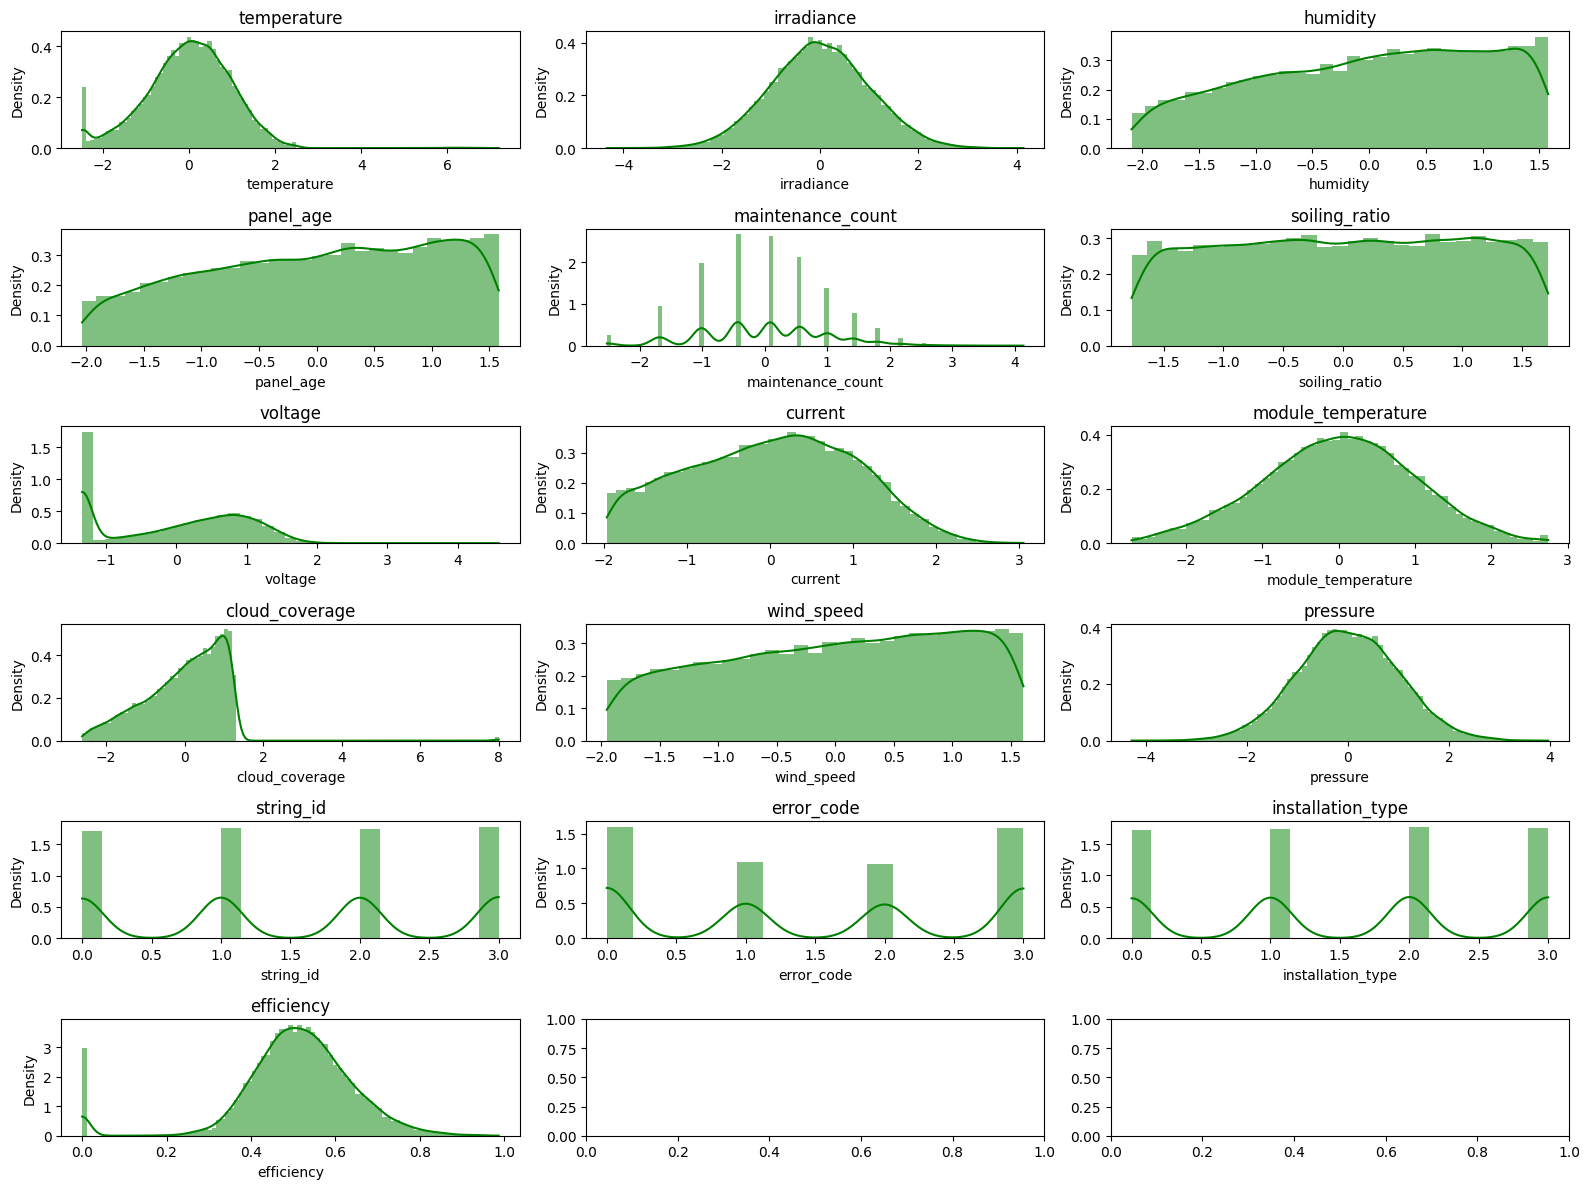

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# List of columns to plot
columns_to_plot = train_df.columns

# Set up the grid layout
grid_layout = (6, 3)

# Create a figure and axes
fig, axes = plt.subplots(*grid_layout, figsize=(16, 12))

# Flatten the 2D array of axes to make it easier to iterate
axes = axes.flatten()

# Iterate through each column and plot a histogram with a curve
for i, column in enumerate(columns_to_plot):
    sns.histplot(train_df[column], kde=True, ax=axes[i], 
                 color='green', stat="density", linewidth=0)
    axes[i].set_title(column)

# Adjust layout to prevent overlapping titles
plt.tight_layout()

# Show the plot
plt.show()

# PyTorch Tabular
[PyTorch Tabular](https://pytorch-tabular.readthedocs.io/en/latest/) is a framework built on [PyTorch](https://pytorch.org), [PyTorch Lightning](https://lightning.ai) and [Pandas](https://pandas.pydata.org). It is a framework that allows you to easily implement state-of-the-art tabular deep learning models like:
- Tabnet
- NODE
- FT-Transformer
- GANDALF 

It has also several other features:
- Self-supervised learning
- To encode categorical columns using the CategoryEmbedding Model.
- To extract the features learnt by a model using the Feature Extractor class.

For more information:  
[Github repo](https://github.com/manujosephv/pytorch_tabular)  
[Paper](https://arxiv.org/abs/2104.13638)

## Setup
All model classes share a number of core configurations that need to be defined before any model can be implemented.

In [32]:
features

['temperature',
 'irradiance',
 'humidity',
 'panel_age',
 'maintenance_count',
 'soiling_ratio',
 'voltage',
 'current',
 'module_temperature',
 'cloud_coverage',
 'wind_speed',
 'pressure',
 'string_id',
 'error_code',
 'installation_type']

In [113]:
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
from pytorch_tabular.models.common.heads import LinearHeadConfig

data_config = DataConfig(
    target=['efficiency'], #target should always be a list.
    continuous_cols=features[:-3],
    categorical_cols=features[-3:],
)
trainer_config = TrainerConfig(
    auto_lr_find=False, # Runs the LRFinder to automatically derive a learning rate
    batch_size=64,
    max_epochs=60,
    early_stopping="valid_loss", # Monitor valid_loss for early stopping
    early_stopping_mode = "min", # Set the mode as min because for val_loss, lower is better
    early_stopping_patience=15, # No. of epochs of degradation training will wait before terminating
    checkpoints="valid_loss", # Save best checkpoint monitoring val_loss
    load_best=True, # After training, load the best checkpoint
    accelerator="gpu", # can be 'cpu','gpu', 'tpu', or 'ipu' 
)

optimizer_config = OptimizerConfig()

head_config = LinearHeadConfig(
    layers="128-64", # No additional layer in head, just a mapping layer to output_dim
    dropout=0.2,
    initialization="kaiming" # Kaiming He initialization
).__dict__

# Custom metric: RMSE

In [114]:
import torch
import pandas as pd

def rmse(y_true, y_pred):
    # Handle both pandas Series and PyTorch tensors
    if isinstance(y_true, pd.Series):
        y_true_tensor = torch.tensor(y_true.values, dtype=torch.float32)
    else:
        y_true_tensor = y_true.float()
    
    if isinstance(y_pred, pd.Series):
        y_pred_tensor = torch.tensor(y_pred.values, dtype=torch.float32)
    else:
        y_pred_tensor = y_pred.float()
    
    mse = torch.mean((y_true_tensor - y_pred_tensor) ** 2)
    rmse_value = torch.sqrt(mse)
    
    # Return scalar value for PyTorch Lightning compatibility
    if hasattr(rmse_value, 'cpu'):
        return rmse_value.cpu()
    return rmse_value

# Hyperparameter optimization

In [115]:
from IPython.display import clear_output
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from optuna import Trial
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import KFold
import torch.nn as nn
import numpy as np

class Objective:
    def __init__(self, train_df, features, target, head_config, data_config, optimizer_config, trainer_config):
        
        """
        Based on https://stackoverflow.com/questions/63224426/how-can-i-cross-validate-by-pytorch-and-optuna
        And https://stats.stackexchange.com/questions/380226/cross-validation-and-building-a-final-model-when-using-hyperparameter-optimizati
        """
        self.train_df = train_df
        self.features = features
        self.target = target
        self.head_config = head_config
        self.data_config = data_config
        self.optimizer_config = optimizer_config
        self.trainer_config = trainer_config

    def __call__(self, trial: Trial):
        fold = KFold(n_splits=5, shuffle=True, random_state=1)
        scores = []

        # Set loss function        
        loss = nn.MSELoss()

        # Cross-validation
        for fold_idx, (train_idx, val_idx) in enumerate(fold.split(self.train_df)):
            train_df_k = self.train_df.iloc[train_idx, :]
            val_df_k = self.train_df.iloc[val_idx, :]

            # Define the hyperparameter search space
            params = {
                'num_attn_blocks': trial.suggest_int('num_attn_blocks', 5, 20),
                'attn_dropout': trial.suggest_float('attn_dropout', 0.1, 0.5, log=True),
                'add_norm_dropout': trial.suggest_float('add_norm_dropout', 0.1, 0.5, log=True),
                'ff_dropout': trial.suggest_float('ff_dropout', 0.1, 0.5, log=True),
                'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
            }

            # Define model
            model_config = FTTransformerConfig(
                task="regression",
                head="LinearHead",
                head_config=self.head_config,
                target_range=[(1.0, 10.0)],
                **params
            )

            tabular_model = TabularModel(
                data_config=self.data_config,
                model_config=model_config,
                optimizer_config=self.optimizer_config,
                trainer_config=self.trainer_config,
            )

            tabular_model.fit(train=train_df_k,
                              loss=loss,
                              metrics=[rmse],
                              metrics_prob_inputs=[False])

            # Make predictions on the validation data
            preds = tabular_model.predict(val_df_k[self.features], include_input_features=False)

            # Calculate error
            medae = rmse(val_df_k[self.target], preds[f'{self.target}_prediction'])
            scores.append(medae)
            
            # if True waits to clear the output until new output is available to replace it.
            clear_output(wait=True) 

        return np.mean(scores)

In [116]:
import numpy as np

In [117]:
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [118]:
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [119]:
from sklearn.impute import SimpleImputer


In [120]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns

# Create the imputer (you can use 'mean', 'median', or 'most_frequent')
imputer = SimpleImputer(strategy='mean')

# Fit and transform only on numeric columns
train_df[numeric_cols] = imputer.fit_transform(train_df[numeric_cols])

In [121]:
numeric_cols = test_df.select_dtypes(include=[np.number]).columns
test_df[numeric_cols] = imputer.fit_transform(test_df[numeric_cols])

In [122]:
train_df

,temperature,irradiance,humidity,panel_age,maintenance_count,soiling_ratio,voltage,current,module_temperature,cloud_coverage,wind_speed,pressure,string_id,error_code,installation_type,efficiency
0,-1.461798e+00,2.981458e-01,-0.209258,1.353260,0.083994,6.150617e-01,1.157421,0.383845,-1.353703,5.009804e-01,1.196557,0.586201,0.0,3.0,3.0,0.562096
1,4.945863e-02,-1.041887e+00,-1.980590,0.315154,1.802125,-1.283641e+00,0.668014,-1.531609,-0.168763,8.913644e-03,1.037948,1.258133,3.0,0.0,0.0,0.396447
2,1.616598e+00,7.426669e-01,1.336257,-1.762462,0.083994,7.241862e-01,1.411803,1.775808,1.097742,8.905170e-17,-1.334823,-0.204372,2.0,0.0,3.0,0.573776
3,2.052147e+00,9.322996e-01,1.473734,0.178125,-0.433087,8.099324e-01,1.369926,-0.560946,2.198234,6.144260e-01,0.367896,0.882603,0.0,3.0,0.0,0.629009
4,-1.707871e+00,-1.947823e+00,-0.712139,1.238835,0.997521,-8.488522e-01,-1.341608,-0.632271,-1.993974,-1.981372e+00,-1.755566,-0.440044,1.0,0.0,1.0,0.341874
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-6.031200e-01,3.064456e-16,1.399716,-0.215810,-0.433087,2.470165e-01,0.205567,1.115200,-0.279409,-2.241137e+00,1.151795,0.537254,1.0,2.0,2.0,0.664907
19996,2.056977e+00,-8.149563e-01,1.412425,0.845342,-1.010662,-1.080966e+00,-1.341608,-1.094062,2.743025,5.497263e-01,-1.599179,0.309079,3.0,0.0,1.0,0.354070
19997,-2.096698e+00,6.338132e-01,-0.324359,1.408085,2.174826,-8.681263e-01,0.258084,1.716960,-1.543985,3.846898e-01,-0.541843,-0.327661,3.0,3.0,2.0,0.419734
19998,2.847930e-16,5.238397e-01,-0.147997,0.231199,0.083994,8.418753e-16,-1.341608,-0.441677,-0.704003,8.488560e-01,0.897564,-0.627505,0.0,0.0,2.0,0.661963


In [123]:
test_df.isna().sum()

temperature           0
irradiance            0
humidity              0
panel_age             0
maintenance_count     0
soiling_ratio         0
voltage               0
current               0
module_temperature    0
cloud_coverage        0
wind_speed            0
pressure              0
string_id             0
error_code            0
installation_type     0
dtype: int64

# Markdown

In [124]:
# import optuna

# objective_mse = Objective(train_df, features, target, 
#                           head_config, data_config, 
#                           optimizer_config, trainer_config)

# # Create a study and optimize the objective function
# study_ftt = optuna.create_study(study_name='ft-transformer',
#                             direction='minimize',
#                             sampler=optuna.samplers.TPESampler(seed=42),storage="sqlite:///db.sqlite3",)
# study_ftt.optimize(objective_mse, n_trials=20, show_progress_bar=True) # The number of trials for each process

In [125]:
# best_params_mae = study_ftt.best_params
# print('Best hyperparameters obtained using MAE Loss')
# print(best_params_mae)

# Training

In [126]:
import numpy as np
import torch.nn as nn
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
    
params ={'num_attn_blocks': 7, 'attn_dropout': 0.1097990803659666, 'add_norm_dropout': 0.4031170288036923, 'ff_dropout': 0.2631245451057451, 'learning_rate': 0.001331121608073689}
    
# Define model
model_config = FTTransformerConfig(
    task="regression",
    head = "LinearHead", #Linear Head
    head_config = head_config, # Linear Head Config
    target_range = [(0.0, 1.0)], # Mohs Hardness Scale Range
    **params
)

tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

# Set loss function        
loss = nn.MSELoss()

tabular_model.fit(train=train_df,
                  loss=loss,
                  metrics=[rmse],
                  metrics_prob_inputs=[False])

2025-06-01 17:18:42,404 - {pytorch_tabular.tabular_model:105} - INFO - Experiment Tracking is turned off

Global seed set to 42


2025-06-01 17:18:42,434 - {pytorch_tabular.tabular_model:473} - INFO - Preparing the DataLoaders

2025-06-01 17:18:42,438 - {pytorch_tabular.tabular_datamodule:290} - INFO - Setting up the datamodule for          
regression task

2025-06-01 17:18:42,463 - {pytorch_tabular.tabular_model:521} - INFO - Preparing the Model: FTTransformerModel

...

Trainable params: 330 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 330 K                                                                                                
Total estimated model params size (MB): 1

Output()

2025-06-01 17:21:54,835 - {pytorch_tabular.tabular_model:584} - INFO - Training the model completed

2025-06-01 17:21:54,836 - {pytorch_tabular.tabular_model:1258} - INFO - Loading the best model

c:\Users\venka\Downloads\Zelestra Pytorch tabular\torch_tabular\lib\site-packages\pytorch_lightning\utilities\cloud_io.py:33: LightningDeprecationWarning: `pytorch_lightning.utilities.cloud_io.get_filesystem` has been deprecated in v1.8.0 and will be removed in v2.0.0. Please use `lightning_fabric.utilities.cloud_io.get_filesystem` instead.
  rank_zero_deprecation(


# Submission

In [132]:
import pandas as pd

# Make predictions on the validation data
preds = tabular_model.predict(test_df, include_input_features=False)

Output()

In [133]:
submission = pd.read_csv('C:/Users/venka/Downloads/1a513221-3-dataset/dataset/test.csv')

In [134]:
print(submission['id'].shape)
print(preds.shape)

(12000,)
(12000, 1)


In [135]:
submission_df =pd.DataFrame({'id': submission['id'].values, 'efficiency': preds['efficiency_prediction'].values})

In [136]:
submission_df.to_csv("sub5.csv",index=False)